In [ ]:
import numpy as np
import joblib
import random
import time  # 🕒 시간 측정을 위해 추가
from scipy.ndimage import rotate, shift, zoom
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline

In [ ]:
# ==========================================
# 1. 사용자 정의 전처리 클래스 (수정됨)
# ==========================================
class CustomImagePreprocess(BaseEstimator, TransformerMixin):
    def __init__(self, stroke_target=0.4, target_size=20, final_size=28, noise_threshold=0.02):
        self.stroke_target = stroke_target
        self.target_size = target_size
        self.final_size = final_size
        self.noise_threshold = noise_threshold

    def fit(self, X, y=None):
        return self

    def transform(self, X, y=None):
        # [수정 1] 입력 데이터가 2차원(flatten)인 경우 3차원(이미지)으로 변환하여 처리 준비
        X = np.array(X)
        if X.ndim == 2:
            # 784 -> 28x28로 변환 (MNIST 기준)
            size = int(np.sqrt(X.shape[1]))
            X = X.reshape(-1, size, size)

        processed_data = []

        # [수정 2] 각 이미지에 대해 정의해둔 전처리 함수 적용
        for img in X:
            img = self.normalize_scale(img)
            img = self.remove_noise(img)
            img = self.normalize_stroke(img)
            img = self.normalize_size(img)
            img = self.center_align(img)

            # [수정 3] 처리 후 다시 1차원(Flatten)으로 변환하여 리스트에 추가
            processed_data.append(img.flatten())

        return np.array(processed_data)

    # --- 내부 메서드 (기존과 동일) ---
    def normalize_scale(self, img):
        img = img.astype(np.float32)
        if img.max() > 1: img = img / 255.0
        return img

    def remove_noise(self, img):
        img = img.copy()
        img[img < self.noise_threshold] = 0.0
        return img

    def normalize_stroke(self, img):
        mask = img > 0.05
        if mask.sum() == 0: return img
        mean_val = img[mask].mean()
        if mean_val == 0: return img
        scale_factor = self.stroke_target / mean_val
        img = img * scale_factor
        img = np.clip(img, 0, 1)
        return img

    def normalize_size(self, img):
        coords = np.where(img > 0.05)
        if coords[0].size == 0: return np.zeros((self.final_size, self.final_size))
        r1, r2 = coords[0].min(), coords[0].max()
        c1, c2 = coords[1].min(), coords[1].max()
        digit = img[r1:r2+1, c1:c2+1]
        h, w = digit.shape
        if h == 0 or w == 0: return np.zeros((self.final_size, self.final_size))
        zoom_h = self.target_size / h
        zoom_w = self.target_size / w
        digit_resized = zoom(digit, (zoom_h, zoom_w))
        return digit_resized

    def center_align(self, img):
        canvas = np.zeros((self.final_size, self.final_size))
        h, w = img.shape
        if h > self.final_size or w > self.final_size:
            h_start = (h - self.final_size) // 2
            w_start = (w - self.final_size) // 2
            img = img[h_start:h_start+self.final_size, w_start:w_start+self.final_size]
            h, w = img.shape
        y0 = (self.final_size - h) // 2
        x0 = (self.final_size - w) // 2
        canvas[y0:y0+h, x0:x0+w] = img
        return canvas

In [ ]:
# ==========================================
# 2. 데이터 증강 함수
# ==========================================
def apply_augment_single(img, mode, rotate_range=15, shift_range=2, zoom_range=0.1):
    if mode == 'rotate':
        angle = random.uniform(-rotate_range, rotate_range)
        img = rotate(img, angle, reshape=False, mode='constant', cval=0)
    elif mode == 'shift':
        dx = random.uniform(-shift_range, shift_range)
        dy = random.uniform(-shift_range, shift_range)
        img = shift(img, [dy, dx], mode='constant', cval=0)
    elif mode == 'zoom':
        factor = random.uniform(1.0, 1.0 + zoom_range)
        h, w = img.shape
        zoomed_img = zoom(img, factor, mode='constant', cval=0)
        zh, zw = zoomed_img.shape
        start_h = max((zh - h) // 2, 0)
        start_w = max((zw - w) // 2, 0)
        img = zoomed_img[start_h:start_h+h, start_w:start_w+w]
        if img.shape != (28, 28):
            img = img[:28, :28]
    return img

def custom_augment(X, y, multiplier=1):
    if multiplier <= 1:
        return X, y

    X = np.array(X)
    y = np.array(y)

    if X.ndim == 2:
        X_reshaped = X.reshape(-1, 28, 28)
    else:
        X_reshaped = X

    X_out = []
    y_out = []

    for img, label in zip(X_reshaped, y):
        X_out.append(img)
        y_out.append(label)
        for _ in range(multiplier - 1):
            mode = random.choice(['rotate', 'shift', 'zoom'])
            aug_img = apply_augment_single(img, mode)
            X_out.append(aug_img)
            y_out.append(label)

    X_out = np.array(X_out).reshape(len(X_out), -1)
    y_out = np.array(y_out)
    return X_out, y_out

In [ ]:
# ==========================================
# 3. 데이터 로드 및 전처리 (전처리 -> 분할 -> 증강)
# ==========================================
def load_preprocess_and_augment(hand_path, org_path, augment_factor=1):
    print(f"\n[Data Prep] Loading & Preprocessing... Augment Factor: {augment_factor}x")

    try:
        d_hand = np.load(hand_path, allow_pickle=True)
        X_hand, y_hand = d_hand['x_train'], d_hand['y_train'].astype(int)

        d_org = np.load(org_path, allow_pickle=True)
        X_org, y_org = d_org['x_train'], d_org['y_train'].astype(int)
    except Exception as e:
        print(f"Error loading files: {e}")
        return None, None, None, None

    # 전처리
    preprocessor = CustomImagePreprocess()
    print("  - Preprocessing Handmade data...")
    X_hand_processed = preprocessor.transform(X_hand)
    print("  - Preprocessing Original MNIST data...")
    X_org_processed = preprocessor.transform(X_org)

    # 분할
    X_hand_tr, X_hand_te, y_hand_tr, y_hand_te = train_test_split(
        X_hand_processed, y_hand, test_size=0.2, random_state=42, stratify=y_hand
    )
    X_org_tr, X_org_te, y_org_tr, y_org_te = train_test_split(
        X_org_processed, y_org, test_size=0.2, random_state=42, stratify=y_org
    )

    # 증강
    if augment_factor > 1:
        print(f"  - Augmenting Handmade Train ({len(X_hand_tr)} -> {augment_factor}x)...")
        X_hand_tr, y_hand_tr = custom_augment(X_hand_tr, y_hand_tr, multiplier=augment_factor)

    # 병합
    X_train = np.concatenate([X_hand_tr, X_org_tr])
    y_train = np.concatenate([y_hand_tr, y_org_tr])
    X_test = np.concatenate([X_hand_te, X_org_te])
    y_test = np.concatenate([y_hand_te, y_org_te])

    print(f"  - Final Train Size: {X_train.shape}, Test Size: {X_test.shape}")
    return X_train, X_test, y_train, y_test

In [ ]:
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve

# ==========================================
# (추가) 학습 곡선 그리기 함수
# ==========================================
def plot_learning_curve_graph(estimator, title, X, y, cv=3, n_jobs=12, train_sizes=np.linspace(0.1, 1.0, 5)):
    plt.figure(figsize=(10, 6))
    plt.title(title)
    plt.xlabel("Training examples")
    plt.ylabel("Score")

    # 학습 곡선 계산
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=cv, n_jobs=n_jobs, train_sizes=train_sizes, scoring='accuracy'
    )

    # 평균과 표준편차 계산
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)

    plt.grid()

    # 학습 점수 영역 (빨간색)
    plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.1, color="r")
    plt.plot(train_sizes, train_scores_mean, 'o-', color="r", label="Training score")

    # 검증 점수 영역 (초록색)
    plt.fill_between(train_sizes, test_scores_mean - test_scores_std,
                     test_scores_mean + test_scores_std, alpha=0.1, color="g")
    plt.plot(train_sizes, test_scores_mean, 'o-', color="g", label="Cross-validation score")

    plt.legend(loc="best")
    return plt

# ==========================================
# 4. 실험 실행 함수 (수정됨: 학습 곡선 추가)
# ==========================================
def run_experiment(scenario_name, X_train, X_test, y_train, y_test):
    print(f"\n{'='*60}")
    print(f"▶ Scenario: {scenario_name}")
    print(f"{'='*60}")

    param_dist = {
        'n_estimators': [100, 300, 500],
        'max_depth': [None, 10, 20, 30],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4],
        'max_leaf_nodes': [None, 16, 32],
        'max_features': ['sqrt', 'log2'],
        'bootstrap': [True, False]
    }

    print("  - Starting Randomized Search (RF Only)...")
    rf = RandomForestClassifier(random_state=42)

    random_search = RandomizedSearchCV(
        rf, param_distributions=param_dist,
        n_iter=30, cv=3, scoring='accuracy', n_jobs=12, verbose=1, random_state=42
    )

    # 🕒 [시간 측정 시작]
    start_time = time.time()

    random_search.fit(X_train, y_train)

    # 🕒 [시간 측정 종료]
    end_time = time.time()
    training_time = end_time - start_time
    print(f"  🕒 Training Time: {training_time:.2f} seconds")

    best_rf_model = random_search.best_estimator_
    print(f"\n  ★ Best Parameters: {random_search.best_params_}")

    # ==========================================
    # (추가) 학습 곡선 실행 및 저장
    # ==========================================
    print("  - Calculating Learning Curve... (This may take a while)")
    lc_plot = plot_learning_curve_graph(
        best_rf_model,
        f"Learning Curve ({scenario_name})",
        X_train, y_train,
        cv=3, n_jobs=12
    )
    lc_filename = f"LearningCurve_{scenario_name}.png"
    lc_plot.savefig(lc_filename)
    print(f"  >> [Saved] Learning curve saved to '{lc_filename}'")
    plt.show()  # 노트북에서 바로 보기

    # 평가
    y_pred = best_rf_model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"  - Final Test Accuracy: {acc:.4f}")
    print(classification_report(y_test, y_pred))

    # 파이프라인 조립 및 저장
    full_pipeline = Pipeline([
        ('prep', CustomImagePreprocess()),
        ('rf', best_rf_model)
    ])

    save_filename = f"pipeline_model_{scenario_name}.pkl"
    joblib.dump(full_pipeline, save_filename)
    print(f"  >> [Saved] Pipeline saved to '{save_filename}'")

    return acc, training_time


[Data Prep] Loading & Preprocessing... Augment Factor: 1x
  - Preprocessing Handmade data...
  - Preprocessing Original MNIST data...
  - Final Train Size: (40896, 784), Test Size: (10224, 784)

▶ Scenario: HandAug_1x_Preprocessed_rf
  - Starting Randomized Search (RF Only)...
Fitting 3 folds for each of 30 candidates, totalling 90 fits


Exception ignored in: <function ResourceTracker.__del__ at 0x7ffff138e980>
Traceback (most recent call last):
  File "/home/yc54616/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/home/yc54616/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/home/yc54616/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
/home/yc54616/anaconda3/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
Exception ignored in: <function ResourceTracker.__del__ at 0x7ffff138e980>
Traceback (most recent call last):
  File "/home/yc54616/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/home/yc54616/anaconda3/lib/python3.13

  🕒 Training Time: 1870.76 seconds

  ★ Best Parameters: {'n_estimators': 500, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_leaf_nodes': None, 'max_features': 'sqrt', 'max_depth': 20, 'bootstrap': False}
  - Calculating Learning Curve... (This may take a while)


Exception ignored in: <function ResourceTracker.__del__ at 0x7ffff138e980>
Traceback (most recent call last):
  File "/home/yc54616/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/home/yc54616/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/home/yc54616/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x7ffff138e980>
Traceback (most recent call last):
  File "/home/yc54616/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/home/yc54616/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/home/yc54616/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTrac

  >> [Saved] Learning curve saved to 'LearningCurve_HandAug_1x_Preprocessed_rf.png'


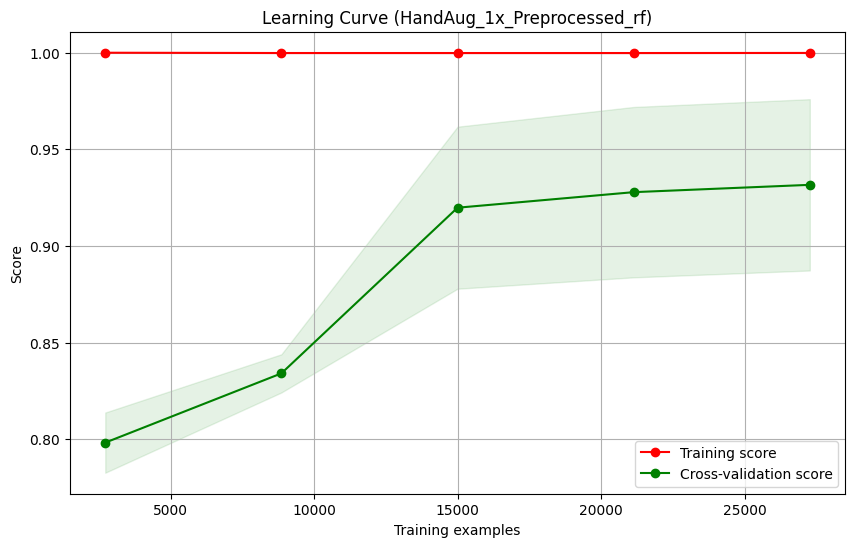

  - Final Test Accuracy: 0.9550
              precision    recall  f1-score   support

           0       0.98      0.98      0.98      1022
           1       0.97      0.95      0.96      1022
           2       0.95      0.95      0.95      1022
           3       0.95      0.95      0.95      1023
           4       0.91      0.96      0.94      1023
           5       0.96      0.95      0.96      1022
           6       0.97      0.97      0.97      1023
           7       0.94      0.96      0.95      1022
           8       0.96      0.94      0.95      1022
           9       0.95      0.93      0.94      1023

    accuracy                           0.96     10224
   macro avg       0.96      0.96      0.96     10224
weighted avg       0.96      0.96      0.96     10224

  >> [Saved] Pipeline saved to 'pipeline_model_HandAug_1x_Preprocessed_rf.pkl'

[Data Prep] Loading & Preprocessing... Augment Factor: 2x
  - Preprocessing Handmade data...
  - Preprocessing Original MNIST dat

Exception ignored in: <function ResourceTracker.__del__ at 0x7ffff138e980>
Traceback (most recent call last):
  File "/home/yc54616/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/home/yc54616/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/home/yc54616/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes


  - Augmenting Handmade Train (8896 -> 2x)...
  - Final Train Size: (49792, 784), Test Size: (10224, 784)

▶ Scenario: HandAug_2x_Preprocessed_rf
  - Starting Randomized Search (RF Only)...
Fitting 3 folds for each of 30 candidates, totalling 90 fits


Exception ignored in: <function ResourceTracker.__del__ at 0x7ffff138e980>
Traceback (most recent call last):
  File "/home/yc54616/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/home/yc54616/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/home/yc54616/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
/home/yc54616/anaconda3/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
Exception ignored in: <function ResourceTracker.__del__ at 0x7ffff138e980>
Traceback (most recent call last):
  File "/home/yc54616/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/home/yc54616/anaconda3/lib/python3.13

  🕒 Training Time: 2699.04 seconds

  ★ Best Parameters: {'n_estimators': 500, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_leaf_nodes': None, 'max_features': 'sqrt', 'max_depth': 20, 'bootstrap': False}
  - Calculating Learning Curve... (This may take a while)


Exception ignored in: <function ResourceTracker.__del__ at 0x7ffff138e980>
Traceback (most recent call last):
  File "/home/yc54616/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/home/yc54616/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/home/yc54616/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x7ffff138e980>
Traceback (most recent call last):
  File "/home/yc54616/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/home/yc54616/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/home/yc54616/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTrac

  >> [Saved] Learning curve saved to 'LearningCurve_HandAug_2x_Preprocessed_rf.png'


Exception ignored in: <function ResourceTracker.__del__ at 0x7ffff138e980>
Traceback (most recent call last):
  File "/home/yc54616/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/home/yc54616/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/home/yc54616/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes


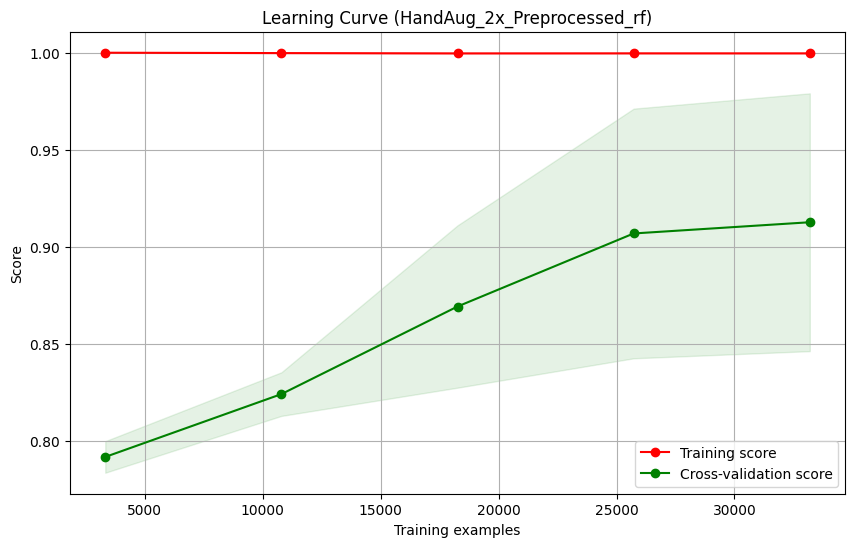

  - Final Test Accuracy: 0.9562
              precision    recall  f1-score   support

           0       0.98      0.99      0.98      1022
           1       0.97      0.95      0.96      1022
           2       0.95      0.95      0.95      1022
           3       0.95      0.96      0.95      1023
           4       0.92      0.97      0.94      1023
           5       0.97      0.95      0.96      1022
           6       0.97      0.97      0.97      1023
           7       0.95      0.95      0.95      1022
           8       0.96      0.94      0.95      1022
           9       0.95      0.93      0.94      1023

    accuracy                           0.96     10224
   macro avg       0.96      0.96      0.96     10224
weighted avg       0.96      0.96      0.96     10224

  >> [Saved] Pipeline saved to 'pipeline_model_HandAug_2x_Preprocessed_rf.pkl'

[Data Prep] Loading & Preprocessing... Augment Factor: 4x
  - Preprocessing Handmade data...
  - Preprocessing Original MNIST dat

Exception ignored in: <function ResourceTracker.__del__ at 0x7ffff138e980>
Traceback (most recent call last):
  File "/home/yc54616/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/home/yc54616/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/home/yc54616/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
/home/yc54616/anaconda3/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
Exception ignored in: <function ResourceTracker.__del__ at 0x7ffff138e980>
Traceback (most recent call last):
  File "/home/yc54616/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/home/yc54616/anaconda3/lib/python3.13

  🕒 Training Time: 4120.81 seconds

  ★ Best Parameters: {'n_estimators': 500, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_leaf_nodes': None, 'max_features': 'sqrt', 'max_depth': 20, 'bootstrap': False}
  - Calculating Learning Curve... (This may take a while)


Exception ignored in: <function ResourceTracker.__del__ at 0x7ffff138e980>
Traceback (most recent call last):
  File "/home/yc54616/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/home/yc54616/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/home/yc54616/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x7ffff138e980>
Traceback (most recent call last):
  File "/home/yc54616/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/home/yc54616/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/home/yc54616/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTrac

  >> [Saved] Learning curve saved to 'LearningCurve_HandAug_4x_Preprocessed_rf.png'


Exception ignored in: <function ResourceTracker.__del__ at 0x7ffff138e980>
Traceback (most recent call last):
  File "/home/yc54616/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/home/yc54616/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/home/yc54616/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes


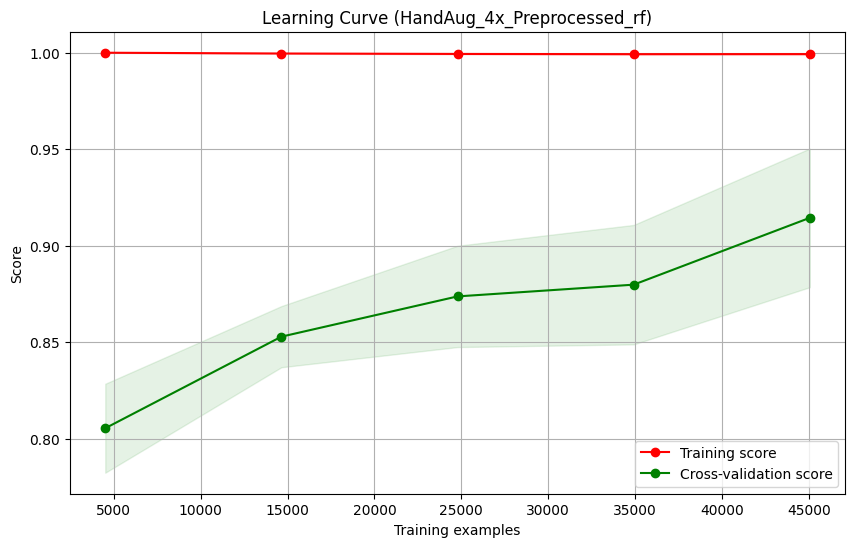

  - Final Test Accuracy: 0.9585
              precision    recall  f1-score   support

           0       0.98      0.98      0.98      1022
           1       0.97      0.95      0.96      1022
           2       0.96      0.95      0.95      1022
           3       0.95      0.96      0.96      1023
           4       0.93      0.97      0.95      1023
           5       0.97      0.95      0.96      1022
           6       0.97      0.98      0.98      1023
           7       0.96      0.95      0.95      1022
           8       0.96      0.95      0.95      1022
           9       0.95      0.94      0.94      1023

    accuracy                           0.96     10224
   macro avg       0.96      0.96      0.96     10224
weighted avg       0.96      0.96      0.96     10224

  >> [Saved] Pipeline saved to 'pipeline_model_HandAug_4x_Preprocessed_rf.pkl'


In [ ]:
# ==========================================
# 5. Main 실행
# ==========================================
hand_file = '../data/final/mnist_final_balanced.npz'
org_file = '../data/final/mnist_sklearn_40000.npz'

factors = [1, 2, 4]

for factor in factors:
    scenario_name = f"HandAug_{factor}x_Preprocessed_rf"
    X_tr, X_te, y_tr, y_te = load_preprocess_and_augment(hand_file, org_file, augment_factor=factor)

    if X_tr is not None:
        run_experiment(scenario_name, X_tr, X_te, y_tr, y_te)